<a href="https://colab.research.google.com/github/MichelLLIUU/Hands-on-ML-with-Pytorch/blob/main/3_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

sklearn.datasets 软件包 主要包含三类函数：fetch_* 函数（如fetch_openml() ），用于下载现实生活中的数据集；load_* 函数，用于加载与 Scikit-Learn 绑定的小型玩具数据集（因此无需通过互联网下载）；make_* 函数，用于生成假数据集，对测试非常有用。生成的数据集通常以(X, y) 元组的形式返回，其中包含输入数据和目标数据，两者都是 NumPy 数组。其他数据集以sklearn.utils.Bunch 对象的形式返回 ，这是一个字典，其条目也可作为属性访问。它们通常包含以下条目：

"DESCR"
数据集描述

"data"
输入数据，通常为二维 NumPy 数组

"target"
标签，通常为一维 NumPy 数组

fetch_openml() 函数有点不同寻常，因为默认情况下，它以 Pandas DataFrame 的形式返回输入，以 Pandas Series 的形式返回标签（除非数据集很稀疏）。但 MNIST 数据集包含图像，而 DataFrames 并不适合图像，因此最好设置as_frame=False ，以 NumPy 数组的形式获取数据。

In [2]:
X, y = mnist.data, mnist.target

In [5]:
X
X.shape


(70000, 784)

In [4]:
y
y.shape

(70000,)

共有 70,000 张图像，每张图像有 784 个特征。这是因为每幅图像都是 28 × 28 像素，每个特征只代表一个像素的强度，从 0（白色）到 255（黑色）。让我们来看看数据集中的一个数字（图 3-1）。我们需要做的就是抓取一个实例的特征向量，将其重塑为一个 28 × 28 的数组，然后使用 Matplotlib 的imshow() 函数显示出来。我们使用cmap="binary" 获得灰度颜色图，其中 0 代表白色，255 代表黑色：

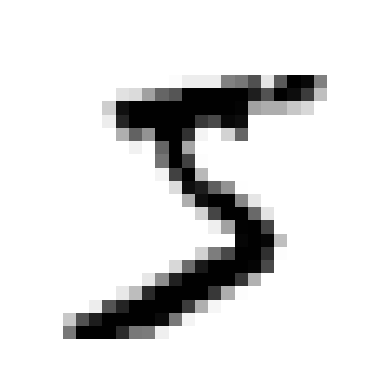

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
y[0]

'5'

为了让大家感受分类任务的复杂性，图 3-2展示了 MNIST 数据集中的几张图片。这里的数字形状种类繁多。尽管如此，这些图像干净整洁、居中、没有过度旋转，而且所有数字的大小大致相同：这个数据集不需要太多预处理（现实世界的数据集通常没那么友好）。

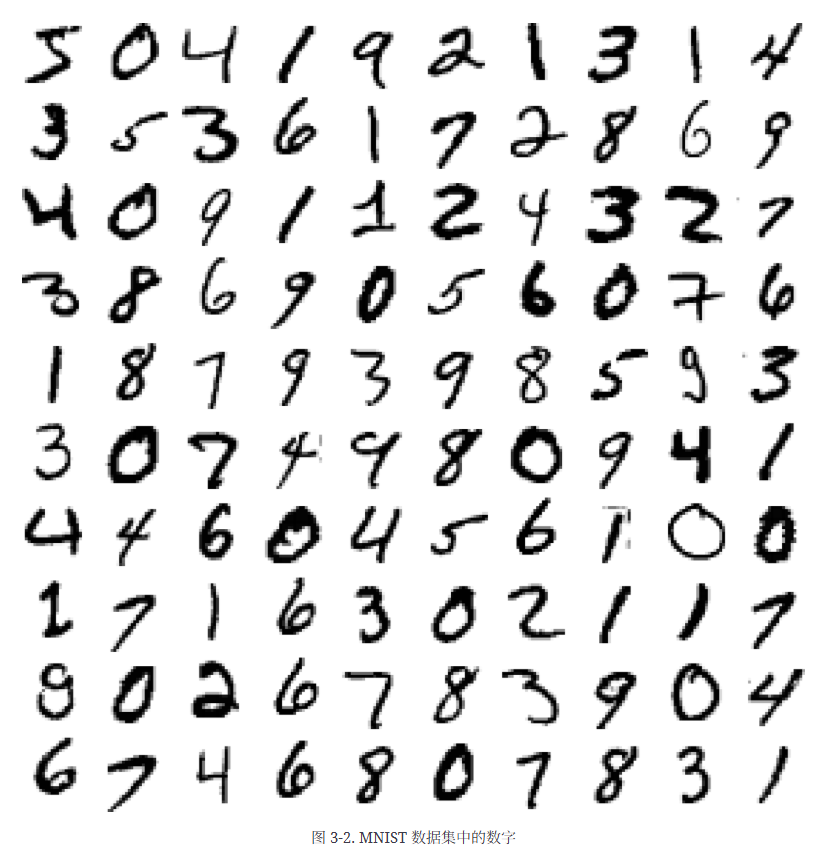

In [8]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

此外，有些学习算法对训练实例的顺序很敏感，如果连续获得很多相似实例，它们的性能就会很差。 数据集的洗牌可以确保这种情况不会发生 。

# 训练二进制分类器

现在，让 来简化问题，只尝试识别一个数字--例如数字 5。这个 "5-检测器 "将是二进制分类器的一个例子，能够区分 5 和非 5 这两个类别。首先，我们将为这项分类任务创建目标向量：

现在，让我们选择一个分类器并对其进行训练。一个好的开始是使用随机梯度下降（SGD，或随机 GD）分类器，使用 Scikit-Learn 的SGDClassifier 类。这种分类器能够高效处理超大数据集。部分原因是 SGD 能够一次一个地独立处理训练实例，这也使得 SGD 非常适合在线学习，稍后您将看到这一点。让我们创建一个SGDClassifier ，并在整个训练集上对它进行训练：

In [9]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [11]:
sgd_clf.predict([some_digit])

array([ True])

# 性能评估

评估分类器 通常比评估回归器要棘手得多，因此本章我们将用大量篇幅来讨论这一主题。有很多性能指标可供使用，所以再拿一杯咖啡，准备学习一堆新概念和缩略语吧！

# 使用交叉验证衡量准确性
评估模型的好方法是使用交叉验证，就像在第 2 章中所做的那样。让我们使用cross_val_score() 函数 来评估我们的SGDClassifier 模型，使用三次k 倍交叉验证。请记住，k-fold 交叉验证意味着将训练集分成k 个折叠 （在本例中是三个），然后训练模型k次，每次取出一个不同的折叠进行评估（参见第 2 章） ：

In [12]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

也可以手写交叉验证

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is
                                       # not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))  # prints 0.95035, 0.96035, and 0.9604

没错，它的准确率超过 90%！这是因为只有大约 10% 的图片是 5，所以如果你总是猜测图片不是5，你就会有大约 90% 的时间是正确的。比诺斯特拉达穆斯还准。

这就说明了为什么**准确率通常不是衡量分类器性能的首选标准**，尤其是在处理偏斜数据集时 （即
某些类别的出现频率远高于其他类别）。评估分类
器性能的更好方法是查看混淆矩阵(CM)。

# **混淆矩阵**
混淆矩阵的一般概念是计算在所有 A/B 对中，A 类实例被分类为 B 类的次数。例如，要知道分类器将 8 和 0 的图像混淆的次数，可以查看混淆矩阵的第 8 行第 0 列。

要计算混淆矩阵，首先需要有一组预测结果，以便与实际目标进行比较。您可以在测试集上进行预测，但最好暂时不要使用测试集**（请记住，只有在项目的最后阶段，当分类器准备好启动时，您才希望使用测试集）**。相反，您可以使用cross_val_predict() 函数 ：

In [13]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [15]:
y_train_pred

array([ True, False, False, ...,  True, False, False])

与cross_val_score() 函数一样，cross_val_predict() 也会执行k 折交叉验证，但它返回的不是评估分数，而是每个测试折上的预测结果。这意味着，您将获得训练集中每个实例的准确预测（我所说的 "准确 "是指 "样本外"：模型对训练期间从未见过的数据进行预测）。

现在可以使用confusion_matrix() 函数获取混淆矩阵了。只需将目标类别 (y_train_5) 和预测类别 (y_train_pred) 传递给它即可：

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

混淆矩阵中的每一行代表一个实际类别 ，而每一列代表一个预测类别。 矩阵的第一行是非 5 图像（负类）： 其中 53 892 张图片被正确分类为非 5 类图片（称为真阴性图片）， ，而其余 687 张图片被错误分类为 5 类图片（假阳性图片 ，也称为I 类错误）。 第二行考虑的是 5s（阳性类）图像： 1,891 张被错误地分类为非 5s（假阴性 ，也称为II 类错误）， ，而其余 3,530 张被正确地分类为 5s（真阳性）。 一个完美的分类器只有真阳性和真阴性，因此其混淆矩阵只有在主对角线上（从左上角到右下角）才有非零值：

>>> y_train_perfect_predictions = y_train_5  # pretend we reached perfection
>>> confusion_matrix(y_train_5, y_train_perfect_predictions)
array([[54579,     0],
       [    0,  5421]])

# 混淆矩阵提供了大量信息，但有时您可能更喜欢更简洁的指标。一个有趣的指标是正向预测的准确度；这被称为分类器的精度（公式 3-1）。

# 等式 3-1. 精确度

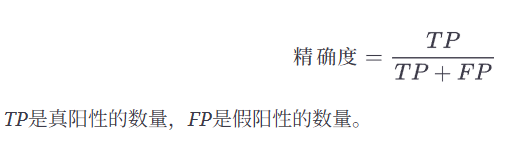

现在考虑一个模型，它只有在非常自信的情况下才会做出正面预测。让我们把它推向极端，假设它总是做出负面预测，除了对它最有信心的实例做出一次正面预测。如果这一次预测是正确的，那么分类器的精度就是 100%（精度 = 1/1 = 100%） 。显然，这样的分类器用处不大，因为它会忽略除了一个正向实例之外的所有实例。因此，精度通常与另一个名为召回 率的指标一起使用， ，也称为灵敏度 或真阳性率（TPR）： ，这是分类器正确检测到的阳性实例的比率（等式 3-2）。

# 等式 3-2. 召回率
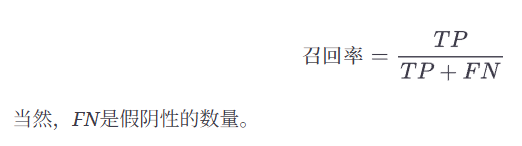

In [17]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [18]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

# 当它声称一张图片代表 5 时，正确率只有 83.7%。而且，它只能检测到 65.1% 的 5。

1分数是精确度和召回率的调和平均值 （等式 3-**3）。常规均值对所有值一视同仁，而调和均值对低值的权重要大得多。因此，分类器只有在召回率和精确率都很高的情况下才能获得较高的F1分数。**

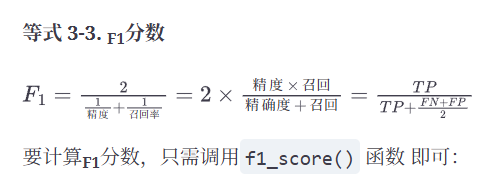

In [19]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

F1分数偏向于精确度和召回率相近的分类器。这并不总是你想要的：在某些情况下，你主要关心的是精度，而在其他情况下，你真正关心的是召回率。例如，如果你训练了一个分类器来检测对儿童安全的视频，那么你可能会更喜欢一个剔除了许多好视频（召回率低）但只保留安全视频（高精度）的分类器，而不是一个召回率高得多但却让一些非常糟糕的视频出现在你的产品中的分类器（在这种情况下，你甚至可能想要添加一个人工管道来检查分类器的视频选择）。另一方面，假设您训练了一个分类器来检测监控图像中的偷窃者：只要您的分类器的召回率达到 99%，即使精确度只有 30%，也没有问题。当然，保安会收到一些错误警报，但几乎所有的偷窃者都会被抓住。同样，医疗诊断通常需要较高的召回率，以避免遗漏重要信息。误报可以通过后续医疗检查排除。

不幸的是，鱼与熊掌不可兼得：提高精确度会降低召回率，反之亦然。这就是所谓的精度/召回权衡。

# 精确度/召回权衡
要理解这种权衡，让我们来看看SGDClassifier 是如何做出分类决策的。对于每个实例，它都会根据决策函数 计算出一个分数。如果得分大于阈值 ，它就会将实例归入正分类；反之，则归入负分类。图 3-4显示了从左侧最低分到右侧最高分的几个数字。假设判定阈值位于中心箭头处（两个 5 之间）：在该阈值的右侧会发现 4 个真阳性（实际为 5），1 个假阳性（实际为 6）。因此，在该阈值下，精确度为 80%（5 个中有 4 个）。但在 6 个实际 5 中，分类器只检测到 4 个，因此召回率为 67%（6 个中有 4 个）。如果提高阈值（将其移动到右侧箭头处），假阳性（6）就会变成真阴性，从而提高精确度（在本例中可达 100%），但一个真阳性就会变成假阴性，使召回率下降到 50%。相反，降低阈值会增加召回率，降低精度。

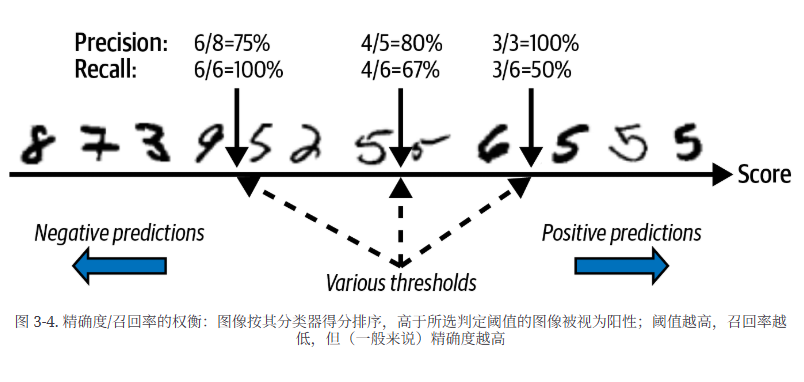

**与其调用分类器的predict() 方法，不如调用分类器的decision_function() 方法 ，该方法会返回每个实例的得分。然后，您可以使用任意阈值，根据这些分数进行预测：**

In [20]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [22]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

SGDClassifier 使用的阈值等于 0，因此前面的代码返回的结果与predict() 方法相同（即True ）。让我们提高阈值：

>>> threshold = 3000
>>> y_some_digit_pred = (y_scores > threshold)
>>> y_some_digit_pred
array([False])
这证实了提高阈值会降低召回率。图像实际上代表了一个 5，当阈值为 0 时，分类器检测到了它，但当阈值提高到 3,000 时，分类器却没有检测到它。

也就是说predict方法就是阈值为0的特殊的decision_function方法。

只不过后者可以自己调整阈值。

如何决定使用哪个阈值？一种方法是使用cross_val_predict() 函数获取训练集中所有实例的得分，但这次要指定返回决策得分而不是预测值：

In [23]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

有了这些分数后，使用precision_recall_curve() 函数 计算所有可能阈值的精确度和召回率（该函数添加了最后一个精确度为 1 和最后一个召回率为 0 的阈值，对应于无限阈值）：

In [24]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

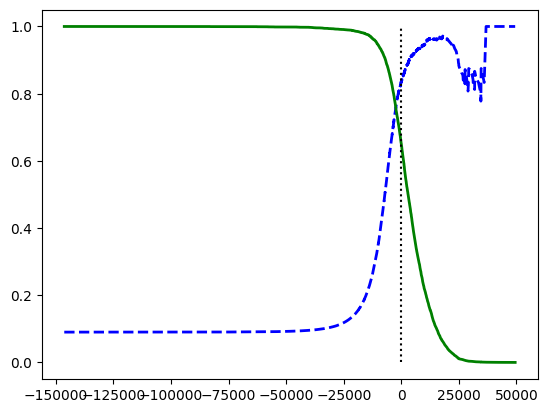

In [25]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.show()

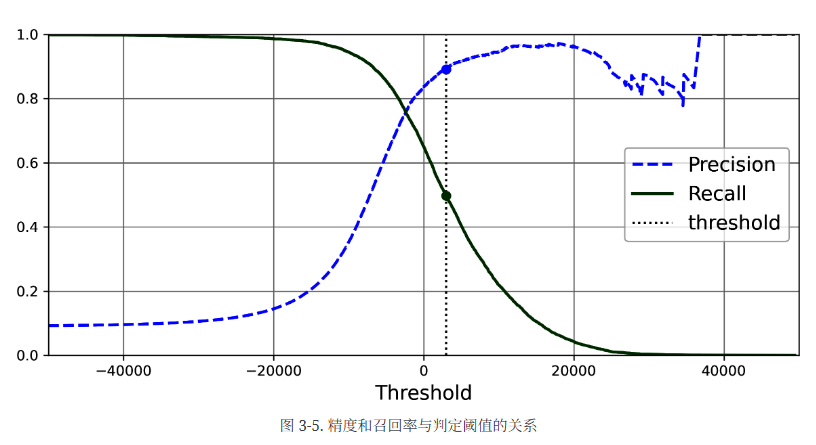

您可能会问，为什么图 3-5 中的精确度曲线 比召回率曲线更颠簸。原因是当你提高阈值时，精确度有时会下降（尽管一般情况下它会上升）。要了解原因，请回看图 3-4，注意从中心阈值开始向右移动一位数时会发生什么：精确度从 4/5（80%）下降到 3/4（75%）。另一方面，召回率只有在阈值增加时才会下降，这也解释了为什么召回率的曲线看起来很平滑。

在此阈值下，精确度接近 90%，召回率约为 50%。选择精确度/召回率折衷值的另一种方法是直接绘制精确度与召回率的对比图，如图 3-6所示（图中显示的是相同的阈值）：

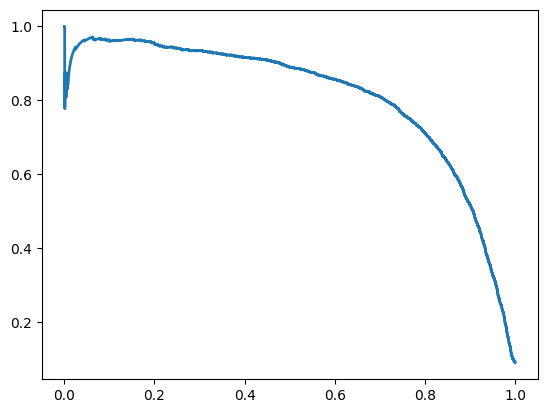

In [26]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

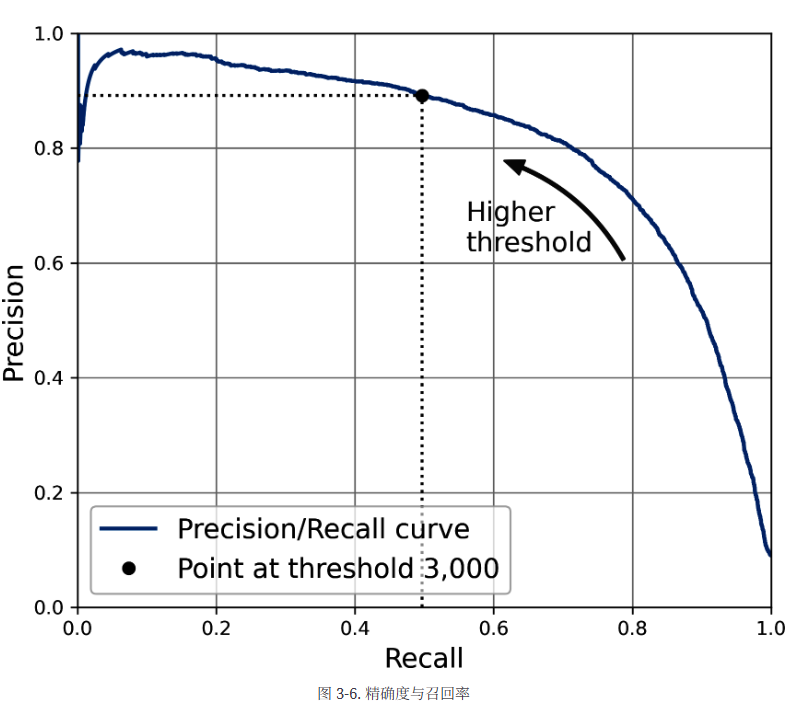

可以看出，在召回率为 80% 左右时，精确度开始急剧下降。您可能希望在精确度/召回率权衡值下降之前选择一个精确度/召回率权衡值--例如，召回率在 60% 左右时。当然，选择取决于你的项目。

假如你决定以 90% 的精确度为目标。你可以使用第一张图来找到你需要使用的阈值，但这并不是很精确。或者，您也可以寻找至少能达到 90% 精度的最低阈值。为此，您可以使用 NumPy 数组的argmax() 方法。该方法会返回最大值的第一个索引，在本例中就是指第一个True 值：

In [28]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

In [29]:
threshold_for_90_precision

np.float64(3370.0194991439557)

要进行预测（暂时在训练集上），可以运行这段代码，而不是调用分类器的predict() 方法：

In [30]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [32]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [33]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706